In [ ]:
# 1.0 Importação das Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import xgboost as xgb
import shap
import joblib


from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, fbeta_score, make_scorer)

 ## 2.0 Contexto do Projeto

 **Objetivo:**
 Construir um modelo de classificação para prever churn de clientes de uma empresa
 de telecomunicações, permitindo ações proativas de retenção antes do cancelamento.

 **Problema de negócio:**
 Reter clientes é mais barato do que adquirir novos. Identificar clientes com alta
 probabilidade de churn permite campanhas de retenção direcionadas e eficientes,
 reduzindo o custo de aquisição e aumentando o LTV (Lifetime Value).

In [ ]:
# 3.0 Entendimento dos Dados

data = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Tamanho do Dataset: {data.shape[0]} linhas e {data.shape[1]} colunas')
data.head()

Tamanho do Dataset: 7043 linhas e 21 colunas


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


 A coluna `customerID` é um identificador único por cliente — sem valor preditivo.
 Verificamos se há duplicatas antes de remover.

In [ ]:
print(f'Proporção de IDs únicos: {data["customerID"].nunique() / data.shape[0]:.2%}')
data.drop('customerID', axis=1, inplace=True)

Proporção de IDs únicos: 100.00%


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


 `SeniorCitizen` está como inteiro (0/1), mas representa uma variável categórica.
 Convertemos para `object` para que seja tratada corretamente pelo pré-processamento.

In [ ]:
data['SeniorCitizen'] = data['SeniorCitizen'].astype('object')

 `TotalCharges` está como `object` em vez de `float64`.
 Existem 11 registros com valor `' '` (espaço vazio) que impedem a conversão direta.
 Verificamos: todos os 11 têm tenure=0 e são os únicos com tenure=0 no dataset —
 clientes sem nenhum mês de permanência que nunca geraram cobrança.
 Imputar a mediana seria inventar um valor sem base real para esses casos.
 Removemos — representam menos de 0.2% do dataset.

In [ ]:
masc1 = data[data['TotalCharges'] == ' '].index
print(f'Registros com TotalCharges vazio: {len(masc1)}')
print(f'tenure desses registros:\n{data.loc[masc1, "tenure"].value_counts()}')
print(f'\nTotal de clientes com tenure=0 no dataset: {(data["tenure"] == 0).sum()}')

data.drop(masc1, inplace=True)
data['TotalCharges'] = data['TotalCharges'].astype('float64')
print(f'\nDataset após limpeza: {data.shape[0]} linhas e {data.shape[1]} colunas')

Registros com TotalCharges vazio: 11
tenure desses registros:
tenure
0    11
Name: count, dtype: int64

Total de clientes com tenure=0 no dataset: 11

Dataset após limpeza: 7032 linhas e 20 colunas


 ## 4.0 Divisão Treino / Teste

 O split é feito **antes** da EDA para evitar data leakage.
 Usar dados de teste na análise exploratória introduziria informações que não
 estariam disponíveis no momento da previsão, levando a uma avaliação superestimada.

 Não utilizamos conjunto de validação separado — a validação cruzada (cv=5)
 cumpre esse papel de forma mais robusta para o tamanho do dataset (~7k linhas).

 `stratify=y` garante que a proporção de classes (73.5% / 26.5%) seja
 preservada em ambos os conjuntos.

In [ ]:
data['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [ ]:
X = data.drop('Churn', axis=1)
y = data['Churn'].map({'Yes': 1, 'No': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino:  {X_train.shape[0]} linhas')
print(f'Teste:   {X_test.shape[0]} linhas')

Treino:  5625 linhas
Teste:   1407 linhas


In [ ]:
# Salva 70 clientes do conjunto de teste para demo do bot
clientes_demo = X_test.sample(70, random_state=42)
clientes_demo.to_csv("clientes_demo.csv", index=False)
print(f"Salvo: {clientes_demo.shape[0]} clientes")

Salvo: 70 clientes


 ## 5.0 Análise Exploratória dos Dados (EDA)

 Separando variáveis por tipo — usamos `X_train` para evitar data leakage.

In [ ]:
var_cat = X_train.select_dtypes(include='object').columns
var_num = X_train.select_dtypes(exclude='object').columns

print(f'Variáveis Categóricas ({len(var_cat)}): {list(var_cat)}\n')
print(f'Variáveis Numéricas   ({len(var_num)}): {list(var_num)}')

Variáveis Categóricas (16): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Variáveis Numéricas   (3): ['tenure', 'MonthlyCharges', 'TotalCharges']


 ### 5.1 Análise Univariada

 Variáveis categóricas — distribuição de contagem por categoria.

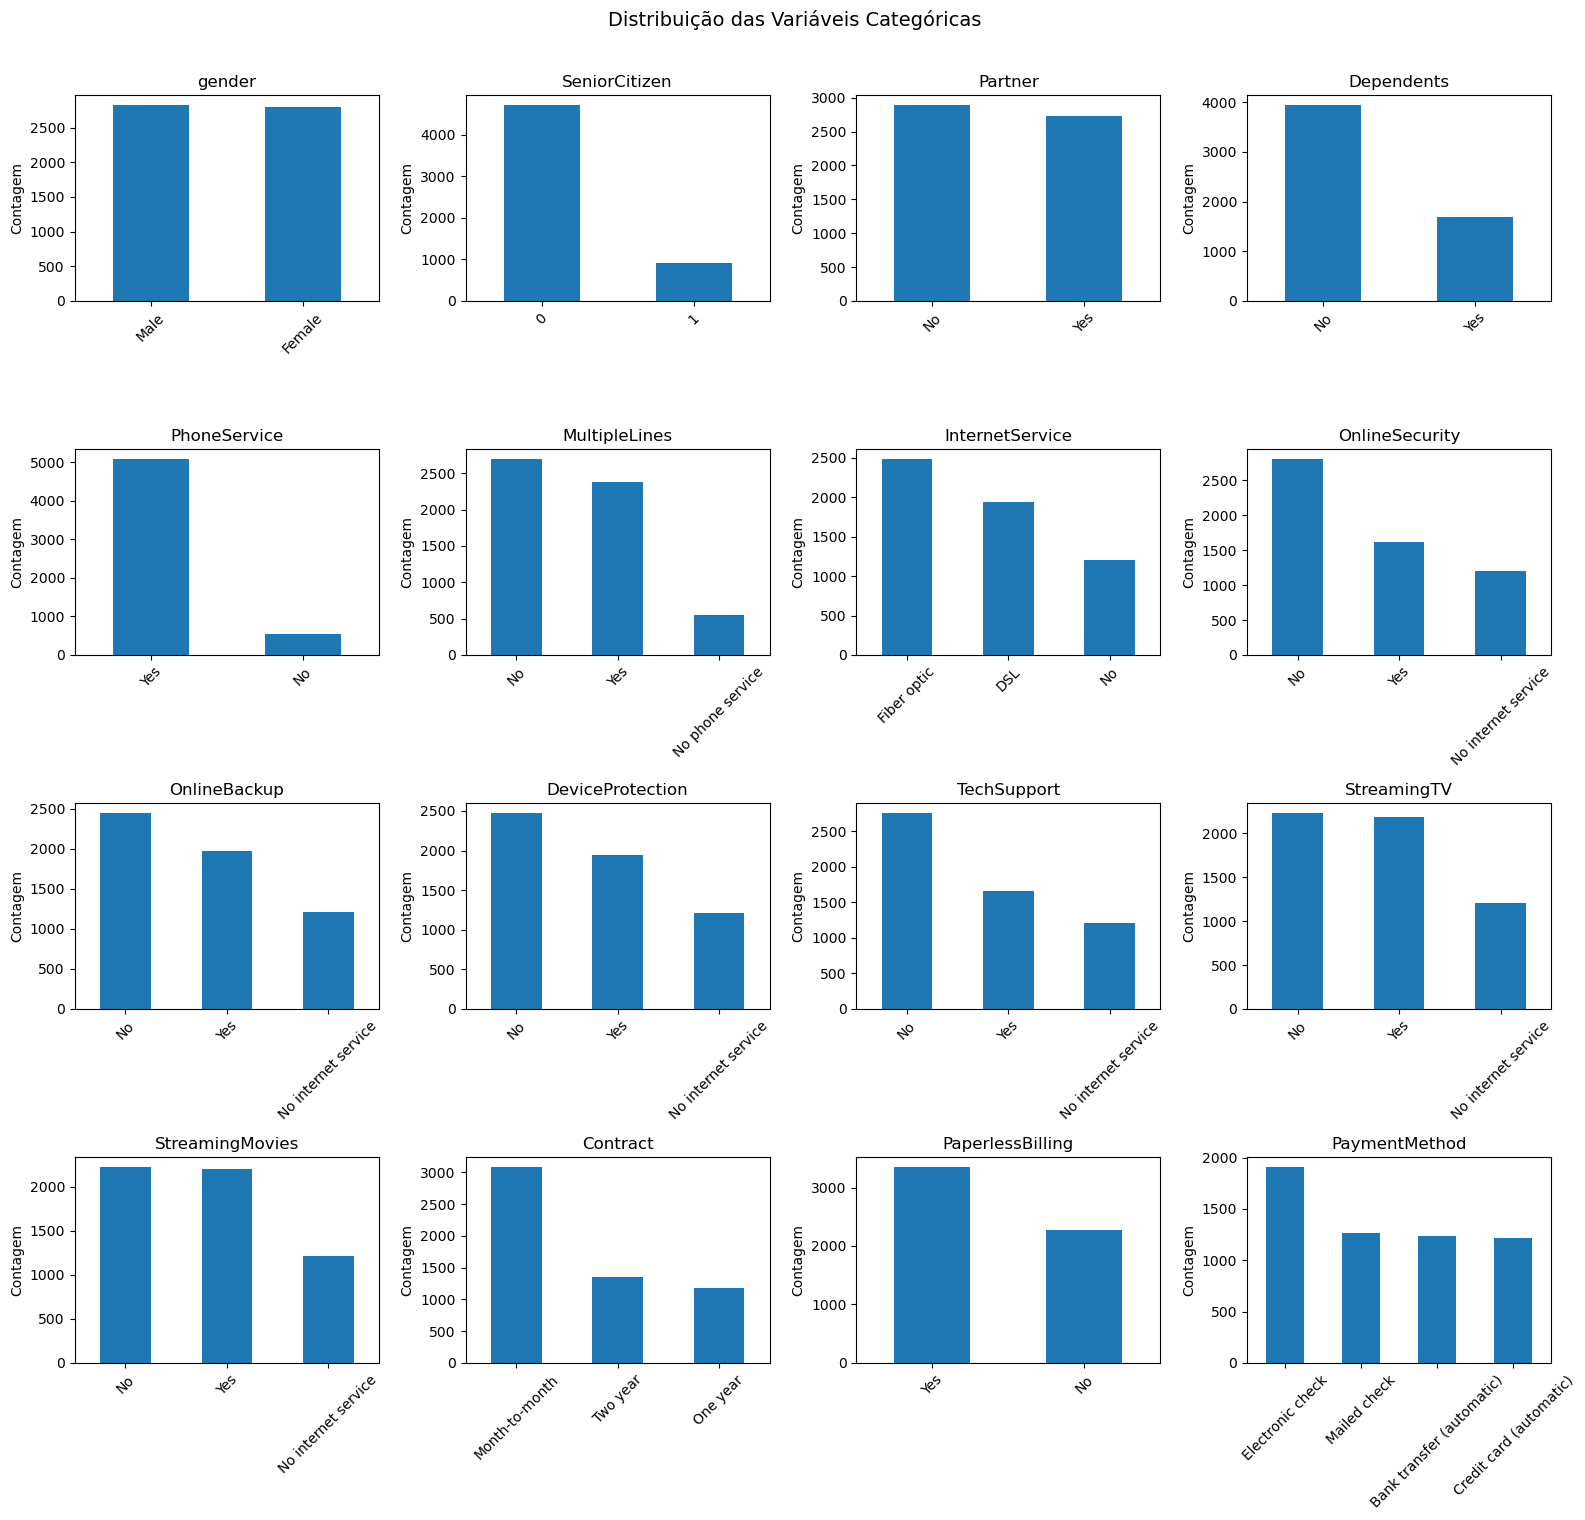

In [ ]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 15))
axes = axes.flatten()
for i, var in enumerate(var_cat):
    X_train[var].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(var)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Contagem')
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle('Distribuição das Variáveis Categóricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

 A maioria das variáveis categóricas apresenta distribuição equilibrada.
 Exceção: `PhoneService` tem proporção muito menor na categoria `No` (~10% dos clientes).

 Variáveis numéricas — histogramas de distribuição.

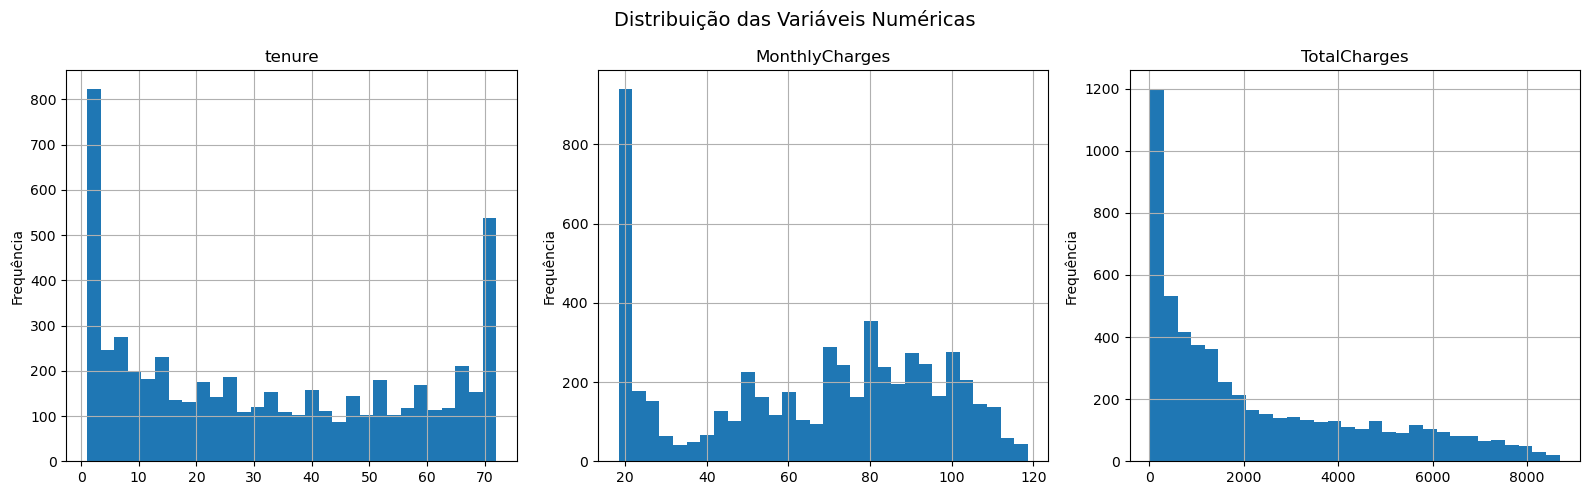

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 5))
for i, var in enumerate(var_num):
    X_train[var].hist(ax=axes[i], bins=30)
    axes[i].set_title(var)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequência')
plt.suptitle('Distribuição das Variáveis Numéricas', fontsize=14)
plt.tight_layout()
plt.show()

 - `tenure`: distribuição bimodal — muitos clientes novos e muitos clientes antigos.
 - `MonthlyCharges`: multimodal — reflexo de diferentes planos contratados.
 - `TotalCharges`: assimétrica positivamente — esperado, pois depende do tempo de permanência.

 ### 5.2 Análise Bivariada

 Correlação entre variáveis numéricas.

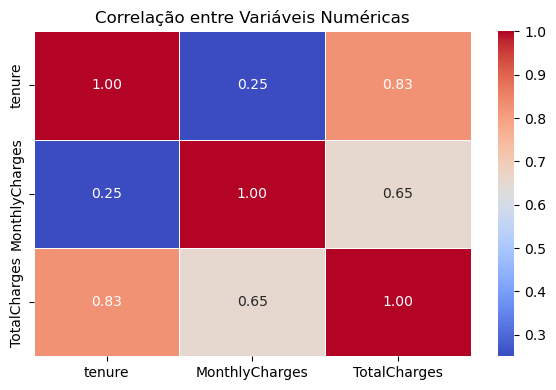

In [ ]:
corr_matrix = X_train[var_num].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlação entre Variáveis Numéricas')
plt.tight_layout()
plt.show()

 `TotalCharges` tem correlação forte com `tenure` (≈0.83) e `MonthlyCharges` (≈0.65).
 Clientes mais antigos naturalmente acumulam maior cobrança total.

 Variáveis numéricas vs Churn — violin plots.
 `TotalCharges` recebe transformação log para melhorar a visualização da distribuição assimétrica.

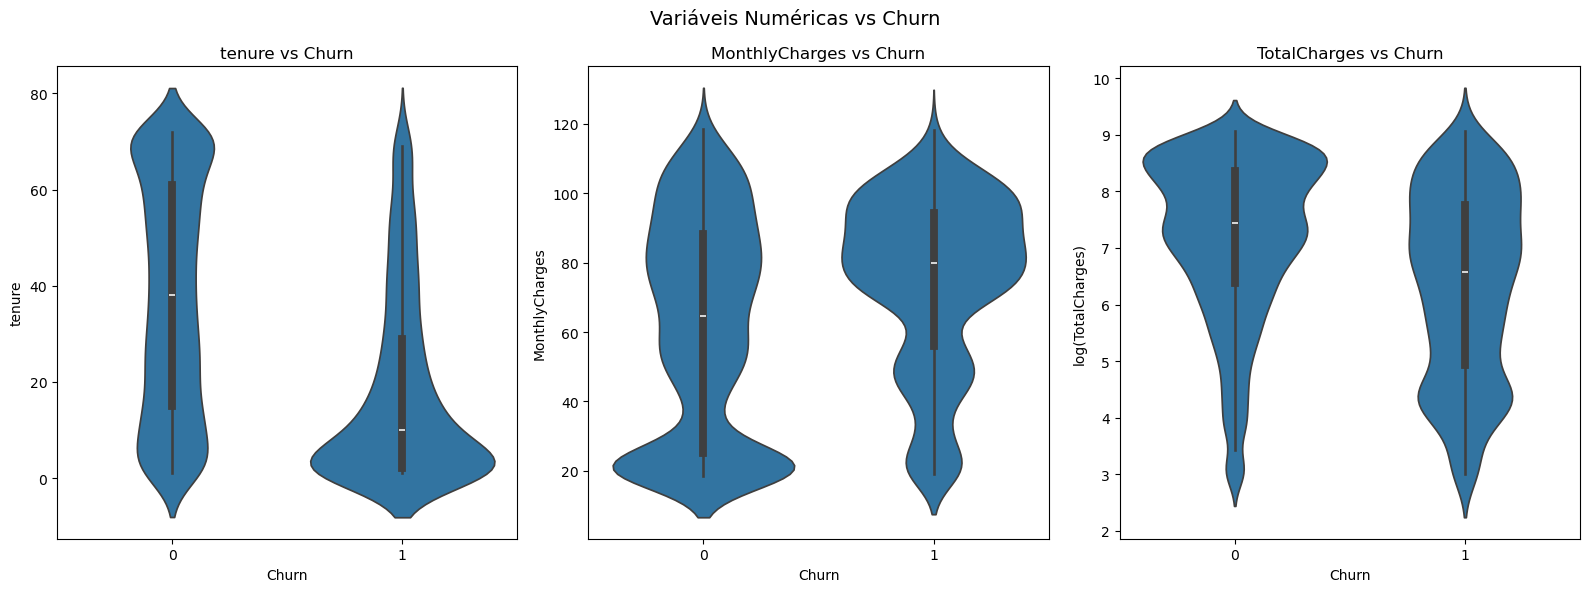

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 6))
for i, var in enumerate(var_num):
    if var == 'TotalCharges':
        sns.violinplot(x=y_train, y=np.log1p(X_train[var]), ax=axes[i])
        axes[i].set_ylabel('log(TotalCharges)')
    else:
        sns.violinplot(x=y_train, y=X_train[var], ax=axes[i])
    axes[i].set_title(f'{var} vs Churn')
    axes[i].set_xlabel('Churn')
plt.suptitle('Variáveis Numéricas vs Churn', fontsize=14)
plt.tight_layout()
plt.show()

 - `tenure`: clientes com churn concentram-se em valores baixos — clientes recentes cancelam mais.
 - `MonthlyCharges`: churn associado a cobranças mensais mais altas.
 - `TotalCharges`: clientes sem churn apresentam densidade em valores mais altos,
   reflexo do maior tempo de permanência (correlação com `tenure`).

 Variáveis categóricas vs Churn — stacked bar normalizado (proporção por categoria).

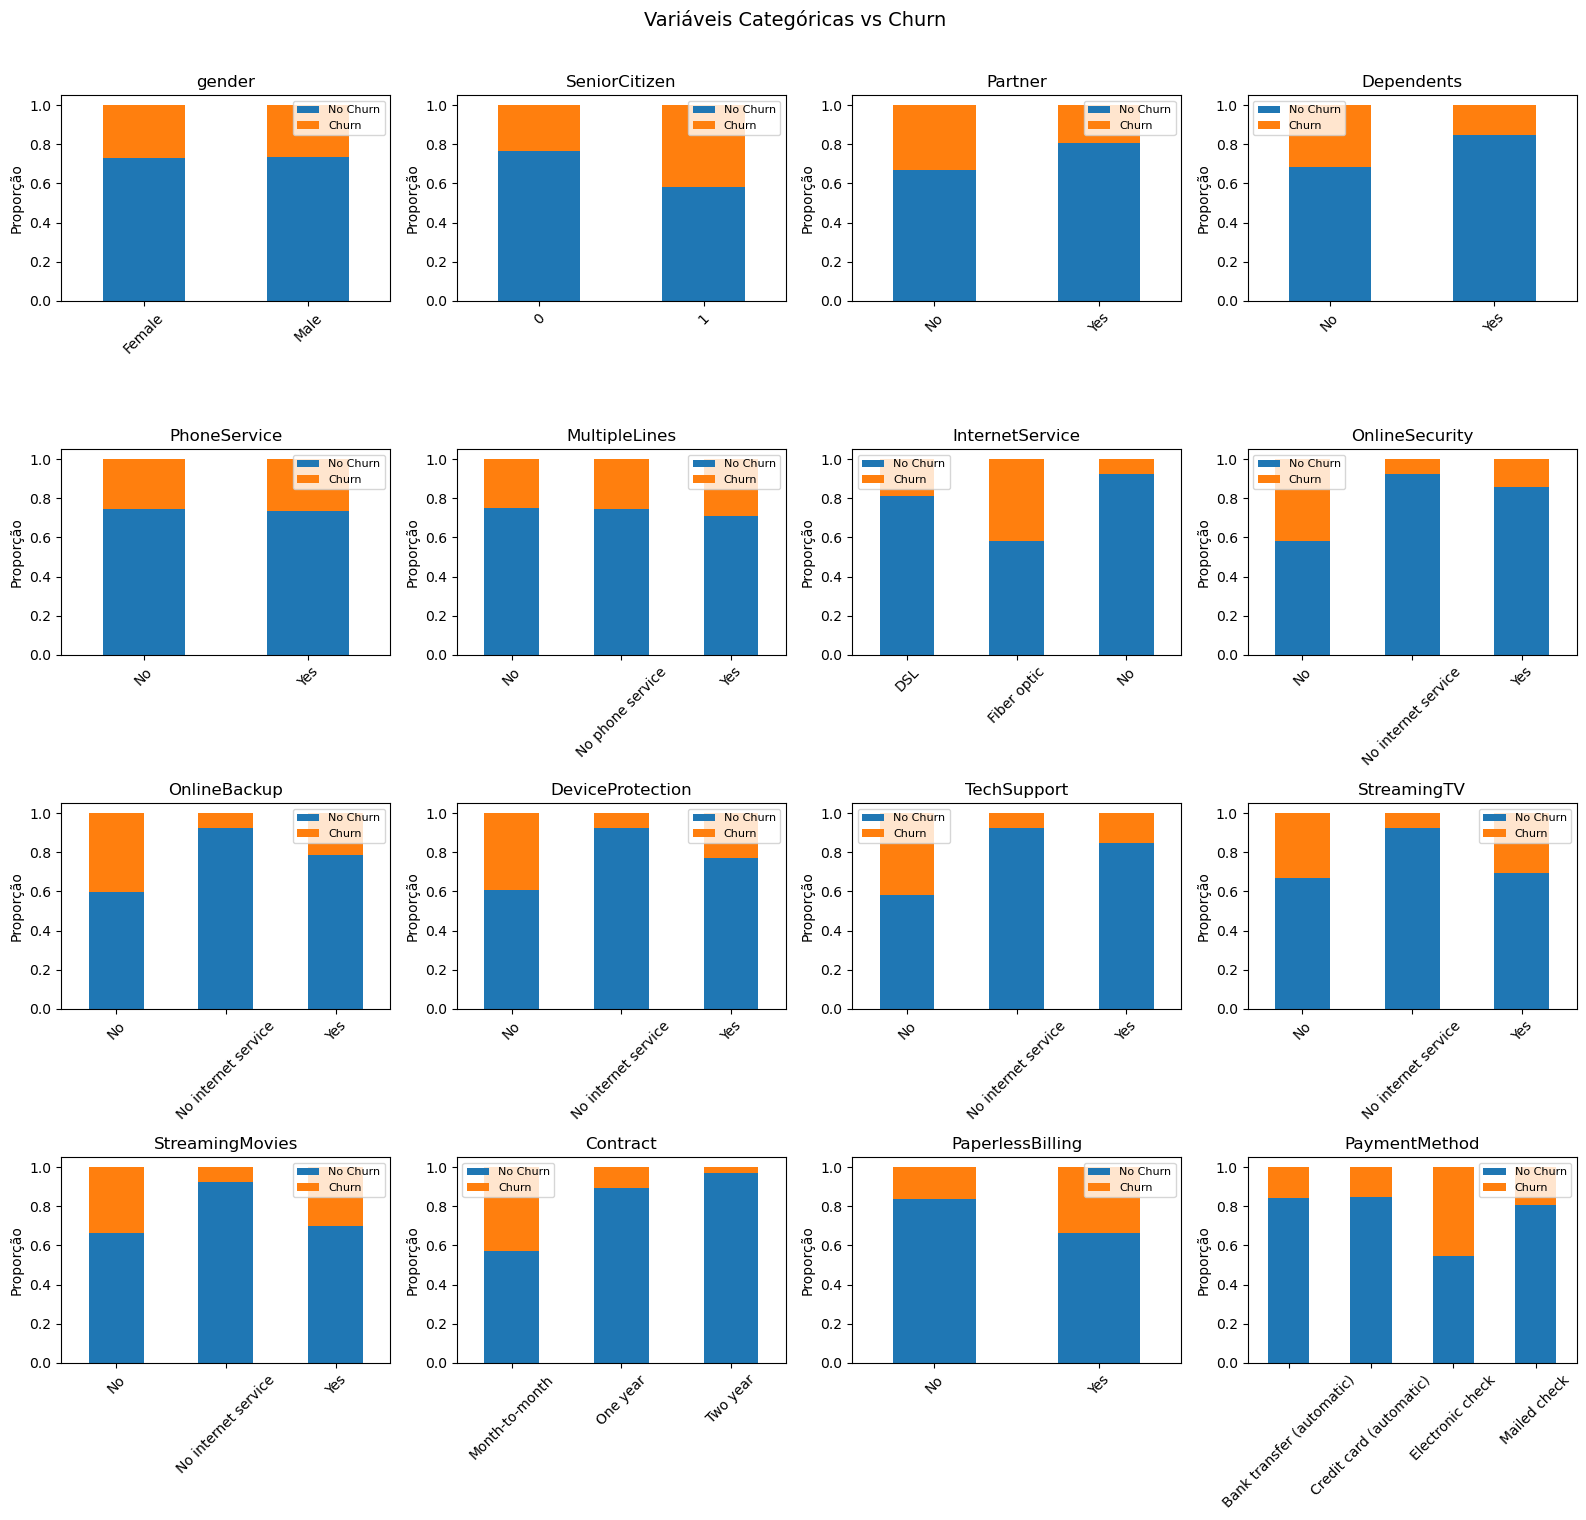

In [ ]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 15))
axes = axes.flatten()
for i, var in enumerate(var_cat):
    pd.crosstab(X_train[var], y_train, normalize='index').plot(
        kind='bar', stacked=True, ax=axes[i]
    )
    axes[i].set_title(var)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Proporção')
    axes[i].legend(['No Churn', 'Churn'], fontsize=8)
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle('Variáveis Categóricas vs Churn', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

 **Sinais fortes de churn:**
 - `Contract`: clientes `Month-to-month` têm taxa de churn muito maior. Contratos longos retêm.
 - `InternetService`: `Fiber optic` concentra maior proporção de churn — possível insatisfação.
 - `SeniorCitizen`: idosos churnam mais que não idosos.
 - `OnlineSecurity` / `TechSupport` / `OnlineBackup` / `DeviceProtection`:
   clientes SEM esses serviços adicionais churnam mais — engajamento com o produto retém.
 - `PaymentMethod`: `Electronic check` destoa com churn consideravelmente maior.

 **Pouco ou nenhum sinal preditivo:**
 - `Gender`: distribuição praticamente idêntica — baixo poder discriminativo esperado.
 - `PhoneService` / `MultipleLines` / `StreamingTV` / `StreamingMovies`: diferenças pequenas.

 ### 5.3 Análise de Segmentos — Contract × InternetService

 Os stacked bars anteriores mostraram que `Contract` e `InternetService` têm
 as maiores diferenças de taxa de churn entre categorias.
 Aqui cruzamos as duas para ver como se combinam por segmento.

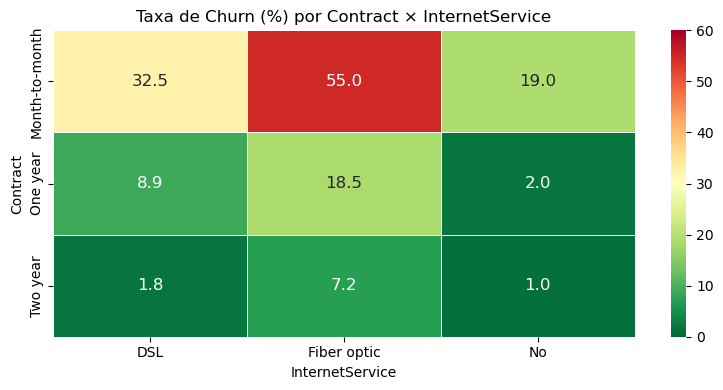

In [ ]:
heatmap_data = pd.crosstab(
    X_train['Contract'],
    X_train['InternetService'],
    values=y_train,
    aggfunc='mean'
) * 100  # taxa de churn em %

plt.figure(figsize=(8, 4))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, vmin=0, vmax=60,
            annot_kws={'size': 12})
plt.title('Taxa de Churn (%) por Contract × InternetService')
plt.ylabel('Contract')
plt.xlabel('InternetService')
plt.tight_layout()
plt.show()

 - **Month-to-month + Fiber optic: 55%** — segmento com maior taxa de churn na base
 - **Month-to-month + DSL: 32.5%** — segundo maior, mas bem abaixo
 - Contratos **One year** e **Two year** reduzem drasticamente o churn em todos os tipos de internet,
   chegando a 1–2% nos contratos de dois anos

 ## 6.0 Pré-processamento — Pipeline Sklearn

 Utilizamos `Pipeline` + `ColumnTransformer` para garantir que as mesmas transformações
 sejam aplicadas de forma consistente no treino, teste e em dados futuros (produção).

 **Escolhas:**
 - `RobustScaler`: robusto a outliers (usa mediana/IQR). Adequado para distribuições
   assimétricas como `TotalCharges`.
 - `OneHotEncoder`: variáveis categóricas com até 4 categorias — sem explosão dimensional.
   `handle_unknown='ignore'` evita erros com categorias novas em produção.

In [ ]:
numerical_pipeline = Pipeline(steps=[
    ('scaler', RobustScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, var_num),
    ('cat', categorical_pipeline, var_cat)
])

 ## 7.0 Baseline — Comparação de Modelos

 Comparamos três modelos com parâmetros default para identificar o melhor ponto de partida.
 Métrica: AUC-ROC via `cross_val_score` (cv=5).
 Matriz de confusão via `cross_val_predict` — sem data leakage.

 **Limitação conhecida:** a correlação forte entre `tenure` e `TotalCharges` (≈0.83),
 observada na EDA, pode subestimar o desempenho da Regressão Logística devido à
 multicolinearidade — modelos baseados em árvores (Random Forest, XGBoost) são
 naturalmente imunes a esse efeito. A comparação do baseline não é inteiramente justa
 para a LR. Ponto a ser tratado em versão futura.


Logistic Regression
AUC-ROC: 0.8457 (+/- 0.0191)
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      4130
           1       0.65      0.55      0.60      1495

    accuracy                           0.80      5625
   macro avg       0.75      0.72      0.73      5625
weighted avg       0.79      0.80      0.80      5625



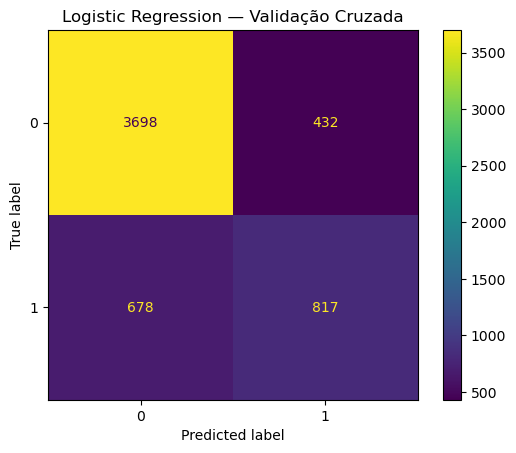


Random Forest
AUC-ROC: 0.8175 (+/- 0.0138)
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      4130
           1       0.62      0.49      0.55      1495

    accuracy                           0.78      5625
   macro avg       0.72      0.69      0.70      5625
weighted avg       0.77      0.78      0.78      5625



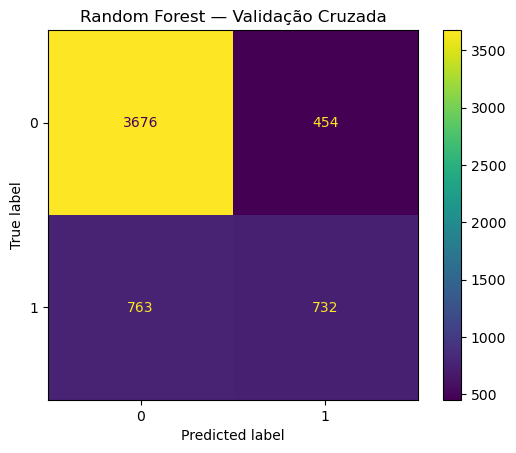


XGBoost
AUC-ROC: 0.8259 (+/- 0.0145)
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      4130
           1       0.61      0.51      0.55      1495

    accuracy                           0.78      5625
   macro avg       0.72      0.69      0.70      5625
weighted avg       0.77      0.78      0.78      5625



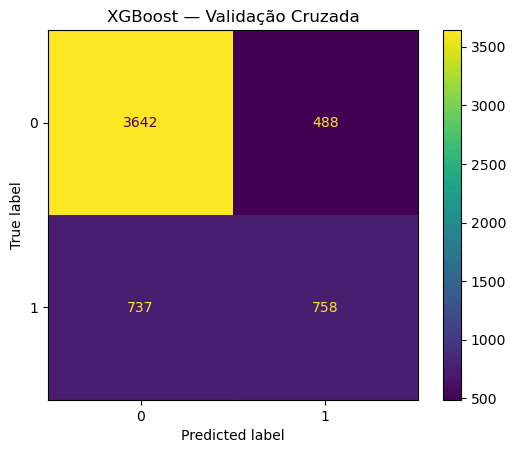

In [ ]:
modelos = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Random Forest',       RandomForestClassifier(random_state=42)),
    ('XGBoost',             xgb.XGBClassifier(eval_metric='logloss', random_state=42))
]

for nome, estimador in modelos:
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', estimador)
    ])

    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='roc_auc')
    y_pred = cross_val_predict(pipeline, X_train, y_train, cv=5)

    print(f'\n{nome}')
    print(f'AUC-ROC: {scores.mean():.4f} (+/- {scores.std():.4f})')
    print(classification_report(y_train, y_pred))

    ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred)).plot()
    plt.title(f'{nome} — Validação Cruzada')
    plt.show()

 **Resultado baseline:**
 - Logistic Regression: AUC-ROC ≈ 0.8457
 - XGBoost:             AUC-ROC ≈ 0.8259
 - Random Forest:       AUC-ROC ≈ 0.8175

 A Regressão Logística superou os modelos mais complexos, indicando que as relações
 entre features e churn são predominantemente lineares neste dataset.

 ## 8.0 Definição da Métrica de Otimização

 O modelo deve identificar clientes com alta probabilidade de churn para ações proativas.
 Os erros têm custos assimétricos:

 - **Falso Negativo** — cliente que vai churnar não é detectado
   → empresa perde receita recorrente sem chance de agir

 - **Falso Positivo** — cliente que não vai churnar é sinalizado como churn
   → empresa realiza campanha de retenção desnecessária (custo operacional)

 Como perder um cliente é mais custoso do que uma campanha desnecessária,
 o Falso Negativo é o erro mais grave. Priorizamos o Recall da classe 1.

 Usamos **F2-score** como métrica de otimização: dá o dobro de peso ao Recall
 em relação à Precision, sem ignorar completamente a Precision
 (evitando um modelo que classifica tudo como churn).

In [ ]:
f2_scorer = make_scorer(fbeta_score, beta=2)

 ## 9.0 Tuning de Hiperparâmetros — Optuna

 Utilizamos Optuna (otimização bayesiana) — mais eficiente que GridSearch/RandomizedSearch.
 Otimizamos os dois melhores modelos do baseline: Logistic Regression e XGBoost.

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
def objective_logistic(trial):
    C            = trial.suggest_float('C', 0.01, 10.0, log=True)
    solver       = trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga'])
    penalty      = trial.suggest_categorical('penalty', ['l1', 'l2'])
    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])

    # 'l1' não é compatível com 'lbfgs'
    if solver == 'lbfgs' and penalty == 'l1':
        return 0.0  # combinação inválida — descarta sem poluir o histórico

    model = LogisticRegression(
        C=C, solver=solver, penalty=penalty,
        class_weight=class_weight, max_iter=1000, random_state=42
    )
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    return cross_val_score(pipeline, X_train, y_train, cv=5, scoring=f2_scorer).mean()

In [ ]:
def objective_xgboost(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'scale_pos_weight':  trial.suggest_float('scale_pos_weight', 1.0, 5.0)
    }
    model = xgb.XGBClassifier(**params, eval_metric='logloss', random_state=42)
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    return cross_val_score(pipeline, X_train, y_train, cv=5, scoring=f2_scorer).mean()

In [ ]:
study_logistic = optuna.create_study(direction='maximize')
study_logistic.optimize(objective_logistic, n_trials=50)

study_xgboost = optuna.create_study(direction='maximize')
study_xgboost.optimize(objective_xgboost, n_trials=50)

print(f'Logistic Regression — Melhor F2: {study_logistic.best_value:.4f}')
print(f'Melhores parâmetros: {study_logistic.best_params}\n')
print(f'XGBoost             — Melhor F2: {study_xgboost.best_value:.4f}')
print(f'Melhores parâmetros: {study_xgboost.best_params}')

Logistic Regression — Melhor F2: 0.7266
Melhores parâmetros: {'C': 2.9829173845059063, 'solver': 'liblinear', 'penalty': 'l1', 'class_weight': 'balanced'}

XGBoost             — Melhor F2: 0.7519
Melhores parâmetros: {'n_estimators': 229, 'max_depth': 4, 'learning_rate': 0.018284550158701583, 'subsample': 0.7263970348385004, 'colsample_bytree': 0.6062289184246441, 'min_child_weight': 6, 'scale_pos_weight': 4.527774392123648}


 **Resultado após tuning** (com class_weight / scale_pos_weight incluídos):
 - Logistic Regression: F2 ≈ 0.7270  (class_weight='balanced')
 - XGBoost:             F2 ≈ 0.7512  ← modelo escolhido

 O XGBoost superou a Logística após incluir o `scale_pos_weight` no espaço de busca,
 o que permitiu ao modelo aprender a penalizar mais os erros na classe minoritária (churn).

 ## 10.0 Modelo Final — Treino e Avaliação no Conjunto de Teste

 Com os melhores hiperparâmetros encontrados, retreinamos em **todo** o conjunto de treino.
 O conjunto de teste é tocado **uma única vez** aqui, simulando dados completamente novos.

 XGBoost teve melhor F2 no tuning (0.7519 vs 0.7269 da Logistic).
 Modelo final escolhido: XGBoost com os melhores parâmetros encontrados pelo Optuna.

In [ ]:
best_xgboost = xgb.XGBClassifier(
    **study_xgboost.best_params, eval_metric='logloss', random_state=42
)
pipeline_final = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', best_xgboost)
])
pipeline_final.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   RobustScaler())]),
                                                  Index(['tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'Intern...
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.018284550158701583, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=4,
                               max_leaves=None, min_child_weight=6, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=229, n_jobs=None,
                               num_parallel_tree=None, ...))])

Avaliação Final — Conjunto de Teste

              precision    recall  f1-score   support

           0       0.92      0.62      0.74      1033
           1       0.45      0.86      0.59       374

    accuracy                           0.69      1407
   macro avg       0.69      0.74      0.67      1407
weighted avg       0.80      0.69      0.70      1407



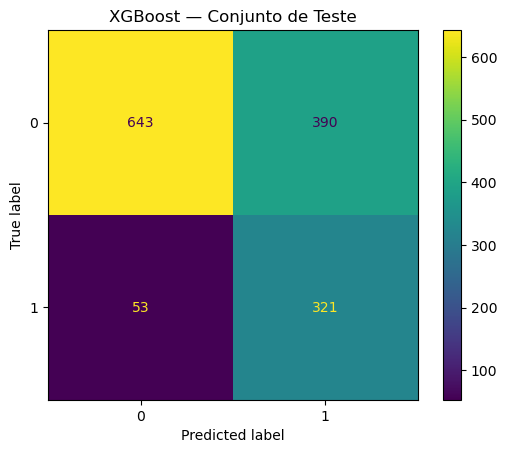

In [ ]:
y_pred_test = pipeline_final.predict(X_test)

print('Avaliação Final — Conjunto de Teste\n')
print(classification_report(y_test, y_pred_test))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test)).plot()
plt.title('XGBoost — Conjunto de Teste')
plt.show()

 ## 11.0 Feature Importance

 ### 11.1 Importância Nativa do XGBoost

 Baseada na frequência com que cada feature é usada para fazer splits nas árvores.
 Rápida e sem dependências extras, mas não indica direção nem magnitude do impacto.

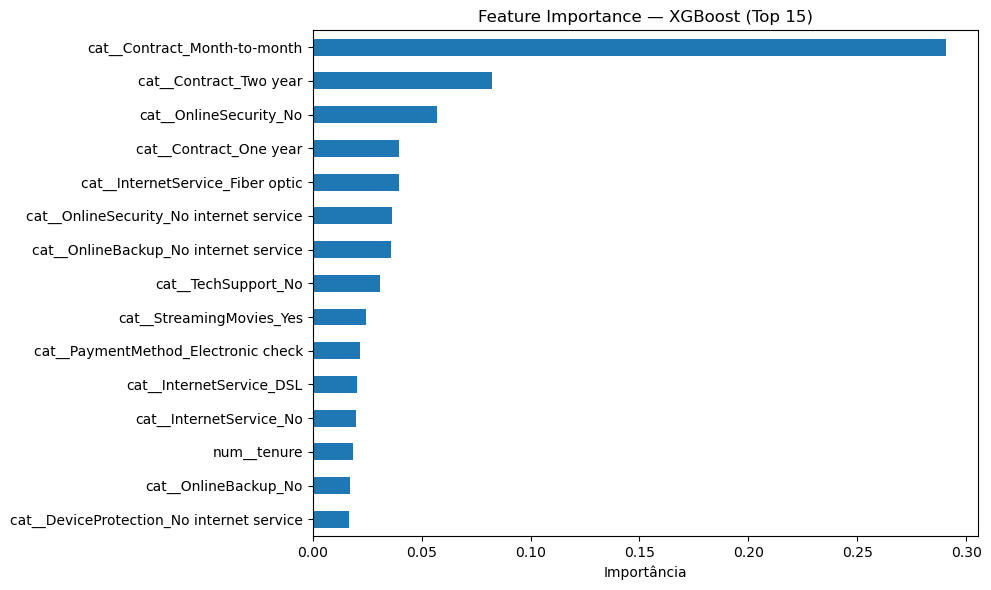

In [ ]:
importances = best_xgboost.feature_importances_
feature_names = pipeline_final[:-1].get_feature_names_out()

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
feat_imp.sort_values().plot(kind='barh')
plt.title('Feature Importance — XGBoost (Top 15)')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()

 ### 11.2 SHAP — Explicabilidade do Modelo

 SHAP (SHapley Additive exPlanations) mostra o impacto real de cada feature
 em cada predição individual — não só frequência de uso, mas direção e magnitude.

 - **Summary plot (beeswarm)**: cada ponto é uma observação do conjunto de teste.
   Cor vermelha = valor alto da feature, azul = valor baixo.
   Posição no eixo X = impacto no score de churn.

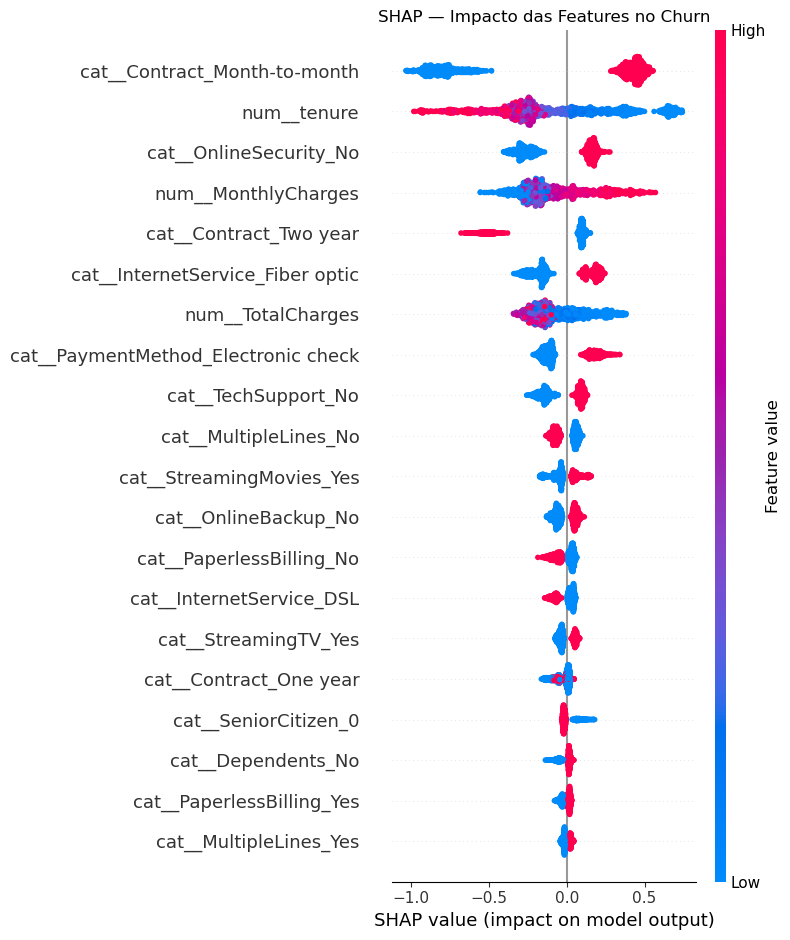

In [ ]:
explainer = shap.TreeExplainer(best_xgboost)

X_test_transformed = pipeline_final[:-1].transform(X_test)
shap_values = explainer.shap_values(X_test_transformed)

plt.figure()
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=False)
plt.title('SHAP — Impacto das Features no Churn')
plt.tight_layout()
plt.show()

 **Leitura do SHAP summary plot:**
 - Features no topo têm maior impacto médio nas predições
 - Pontos à direita (positivo) aumentam a probabilidade de churn
 - Pontos à esquerda (negativo) reduzem a probabilidade de churn

 Isso permite identificar não só quais features importam, mas **como** elas influenciam o modelo.

 ## 12.0 Análise Financeira

 Avaliamos o impacto financeiro do modelo comparando dois cenários:
 - **Sem modelo**: empresa não age, perde todos os clientes que churnam
 - **Com modelo**: empresa aborda clientes sinalizados pelo modelo

 **Premissas:**
 - Custo de campanha de retenção: R$50 por cliente abordado
 - LTV perdido: MonthlyCharges × tenure médio dos clientes com churn
 - Taxa de retenção da campanha: 40% dos clientes abordados corretamente (VP)
   (referência: campanhas de retenção em telecom têm sucesso em 20–40% dos casos)

In [ ]:
# Tenure médio dos clientes que fizeram churn — base para o LTV estimado
tenure_medio_churn = X_train[y_train == 1]['tenure'].mean()
print(f'Tenure médio dos clientes com churn: {tenure_medio_churn:.1f} meses')

custo_campanha   = 50
taxa_retencao    = 0.40  # 40% dos VP abordados são efetivamente retidos

Tenure médio dos clientes com churn: 18.2 meses


In [ ]:
monthly  = X_test['MonthlyCharges'].values
y_actual = y_test.values

vp_idx = (y_pred_test == 1) & (y_actual == 1)  # detectou churn corretamente
fn_idx = (y_pred_test == 0) & (y_actual == 1)  # churn não detectado
fp_idx = (y_pred_test == 1) & (y_actual == 0)  # alarme falso

# Cenário 1 — Sem modelo
perda_sem_modelo = (monthly[y_actual == 1] * tenure_medio_churn).sum()

# Cenário 2 — Com modelo (taxa de retenção de 40%)
# Valor incremental = o que o modelo gerou a mais vs não fazer nada
# Receita salva: VP detectados × 40% retidos × LTV estimado
# Custo: todos os abordados (VP + FP) × custo da campanha
receita_salva   = (monthly[vp_idx] * tenure_medio_churn).sum() * taxa_retencao
custo_campanhas = (vp_idx.sum() + fp_idx.sum()) * custo_campanha
valor_incremental = receita_salva - custo_campanhas

print(f'\nCenário 1 — Sem modelo')
print(f'  Perda estimada com churns:                 R$ {perda_sem_modelo:,.2f}')

print(f'\nCenário 2 — Com modelo (retenção de {taxa_retencao:.0%})')
print(f'  Clientes com churn detectados (VP):        {vp_idx.sum()} de {(y_actual==1).sum()}')
print(f'  Receita salva (VP × 40% retidos):          R$ {receita_salva:,.2f}')
print(f'  Custo campanhas ({vp_idx.sum() + fp_idx.sum()} clientes × R$50):  R$ {custo_campanhas:,.2f}')
print(f'  Valor incremental vs não agir:             R$ {valor_incremental:,.2f}')


Cenário 1 — Sem modelo
  Perda estimada com churns:                 R$ 500,683.88

Cenário 2 — Com modelo (retenção de 40%)
  Clientes com churn detectados (VP):        321 de 374
  Receita salva (VP × 40% retidos):          R$ 173,847.65
  Custo campanhas (711 clientes × R$50):  R$ 35,550.00
  Valor incremental vs não agir:             R$ 138,297.65


 **Interpretação:**

 O valor incremental responde à pergunta direta: quanto a empresa ganha a mais
 usando o modelo versus não fazer nada?

 - Receita salva: churns detectados × taxa de retenção da campanha (40%) × LTV estimado
 - Custo: todos os clientes abordados (VP + FP) × R$50 por campanha

 FN e VP não retidos são perdas que ocorreriam de qualquer forma — não entram no cálculo
 incremental, pois não representam diferença entre agir ou não agir.

 Taxa de retenção de 40%: referência conservadora-realista para o setor de telecom.
 Os Falsos Positivos encarecem a operação sem retorno — coerente com o F2-score,
 que penaliza FN mais do que FP, mas não ignora o custo de precisão baixa.

 ## 13.0 Salvando o Modelo

 Salvamos a pipeline completa (pré-processamento + modelo) em um único arquivo `.pkl`.
 Isso garante que qualquer dado novo passará pelas mesmas transformações automaticamente,
 sem necessidade de pré-processar manualmente antes de chamar o `predict`.

In [ ]:
print(pipeline_final.feature_names_in_)
joblib.dump(pipeline_final, 'model/pipeline_churn.pkl')
print('Modelo salvo em model/pipeline_churn.pkl')

['gender' 'SeniorCitizen' 'Partner' 'Dependents' 'tenure' 'PhoneService'
 'MultipleLines' 'InternetService' 'OnlineSecurity' 'OnlineBackup'
 'DeviceProtection' 'TechSupport' 'StreamingTV' 'StreamingMovies'
 'Contract' 'PaperlessBilling' 'PaymentMethod' 'MonthlyCharges'
 'TotalCharges']
Modelo salvo em model/pipeline_churn.pkl


 Para carregar e usar o modelo futuramente:
 ```python
 pipeline = joblib.load('model/pipeline_churn.pkl')
 predicoes = pipeline.predict(novos_dados)
 ```